In [ ]:
import os
import nltk
import json
import hashlib
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from collections import Counter
from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import euclidean_distances

# ***Seleção de documentos mais coesos e ambíguos***

In [ ]:
def calcular_total_selecionar(N, n_d=None, epsilon=0.005, n_sim=10_000, seed=42):
    if n_d is None:
        n_d = max(1, int(N * 0.01))

    Ku  = max(2, int(N / n_d))
    rng = np.random.default_rng(seed)
    p_uniform = [1 / Ku] * Ku

    melhor_ns     = Ku
    melhor_p_star = float('inf')

    step = max(1, Ku // 5)
    for ns in range(Ku, min(N, Ku * 60), step):
        amostras = rng.multinomial(ns, p_uniform, size=n_sim)
        p_zero   = float(np.mean(np.any(amostras == 0, axis=1)))
        p_star   = abs(p_zero - epsilon)

        if p_star < melhor_p_star:
            melhor_p_star = p_star
            melhor_ns     = ns

        if p_zero < epsilon / 10:
            break

    print(f"Seleção probabilística  →  N={N:,} | n_d={n_d} | K_u={Ku} | n_s={melhor_ns:,} | p*≈{melhor_p_star:.4f}")
    return melhor_ns


In [ ]:
nltk.download("stopwords", quiet=True)
stop_words_multilingue = list(set(
    stopwords.words("english") + stopwords.words("portuguese") + stopwords.words("spanish")
))

# ***Wiki***

***Conhecendo e processando o dataset***

In [ ]:
from datasets import load_dataset
wiki = load_dataset('zli12321/Wiki')

In [ ]:
wiki

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'page_name', 'topic', 'subtopic', 'subjects_top_term'],
        num_rows: 14290
    })
    test: Dataset({
        features: ['id', 'text', 'page_name', 'topic', 'subtopic', 'subjects_top_term'],
        num_rows: 8024
    })
})

In [ ]:
cols_to_analyze = ['topic', 'subtopic']
stats = []

print("--- Análise de Hierarquia por Split ---")
for split in wiki.keys():
    df_split = wiki[split].to_pandas()
    row_data = {'Split': split, 'Instâncias': len(df_split)}

    for col in cols_to_analyze:
        if col in df_split.columns:
            row_data[f'Qtd {col}'] = df_split[col].nunique()
    stats.append(row_data)

display(pd.DataFrame(stats))

print("\n--- Sobreposição de Rótulos (Intersection) ---")
splits = list(wiki.keys())
if len(splits) >= 2:
    s1, s2 = splits[0], splits[1]
    df1 = wiki[s1].to_pandas()
    df2 = wiki[s2].to_pandas()

    for col in cols_to_analyze:
        if col in df1.columns and col in df2.columns:
            set1 = set(df1[col].unique())
            set2 = set(df2[col].unique())
            comum = set1.intersection(set2)
            print(f"Coluna '{col}': {len(comum)} rótulos em comum entre {s1} e {s2}")

--- Análise de Hierarquia por Split ---


,Split,Instâncias,Qtd topic,Qtd subtopic
0,train,14290,15,45
1,test,8024,15,37



--- Sobreposição de Rótulos (Intersection) ---
Coluna 'topic': 15 rótulos em comum entre train e test
Coluna 'subtopic': 37 rótulos em comum entre train e test


In [ ]:
df_train = wiki['train'].to_pandas()
df_train.to_csv('wiki_train.csv', index=False, encoding='utf-8-sig')

print(f"Arquivo 'wiki_train.csv' gerado com sucesso! Total de {len(df_train)} instâncias.")

Arquivo 'wiki_train.csv' gerado com sucesso! Total de 14290 instâncias.


In [ ]:
df_train.head()

,id,text,page_name,topic,subtopic,subjects_top_term
0,2_CicelyMaryBarker,june february english illustrator best known s...,Cicely Mary Barker,Language and literature,Language and literature,"Writers, publishers, and critics"
1,210_GertrudeBarrowsBennett,major female writer fantasy science fiction un...,Gertrude Barrows Bennett,Language and literature,Language and literature,"Writers, publishers, and critics"
2,470_MeraldaWarren,junior warren born june artist poet remote bri...,Meralda Warren,Language and literature,Language and literature,"Writers, publishers, and critics"
3,588_WilhelmBusch,christian april january german poet illustrato...,Wilhelm Busch,Language and literature,Language and literature,"Writers, publishers, and critics"
4,743_GabrielGarcíaMárquez,american spanish march april novelist short st...,Gabriel García Márquez,Language and literature,Language and literature,"Writers, publishers, and critics"


In [ ]:
wiki_jsonl_path = 'wiki.jsonl'
df_train.to_json(wiki_jsonl_path, orient='records', lines=True, force_ascii=False)

print(f"Arquivo '{wiki_jsonl_path}' gerado com sucesso!")

Arquivo 'wiki.jsonl' gerado com sucesso!


In [ ]:
hierarquia_train = df_train.groupby('topic')['subtopic'].unique().to_dict()

print("--- Tópicos e Subtópicos no Split de Treino ---")
for topic, subtopics in hierarquia_train.items():
    print(f"\nTópico: {topic}")
    for sub in sorted(subtopics):
        print(f"  - {sub}")

--- Tópicos e Subtópicos no Split de Treino ---

Tópico: Agriculture, food, and drink
  - Agriculture, food, and drink

Tópico: Art and architecture
  - Architecture
  - Art

Tópico: Engineering and technology
  - Computing and engineering
  - Transport

Tópico: Geography and places
  - Geography
  - Places

Tópico: History
  - Royalty, nobility, and heraldry
  - World history

Tópico: Language and literature
  - Language and literature

Tópico: Mathematics
  - Mathematics and mathematicians

Tópico: Media and drama
  - Film
  - Media and drama
  - Television

Tópico: Music
  - Albums
  - Classical compositions
  - Other music articles
  - Songs

Tópico: Natural sciences
  - Biology and medicine
  - Chemistry and materials science
  - Earth science
  - Physics and astronomy

Tópico: Philosophy and religion
  - Philosophy
  - Religion

Tópico: Social sciences and society
  - Culture, sociology, and psychology
  - Economics and business
  - Education
  - Law
  - Magazines and print journ

***Método CPS***

In [ ]:
import json
import hashlib

def hash_texto_wiki(texto: str) -> str:
    return "wiki_" + hashlib.sha256(texto.strip().encode("utf-8")).hexdigest()[:16]

target_file_wiki = 'wiki.jsonl'
textos_wiki = []
nomes_arquivos_wiki = []
linhas_originais_wiki = {}

print(f"Carregando textos do arquivo {target_file_wiki}...")

with open(target_file_wiki, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        try:
            data = json.loads(line.strip())

            if not data.get('topic'):
                continue

            if 'text' in data and data['text'].strip():
                texto = data['text']
                doc_id = hash_texto_wiki(texto)

                if doc_id in linhas_originais_wiki:
                    continue

                textos_wiki.append(texto)
                nomes_arquivos_wiki.append(doc_id)
                linhas_originais_wiki[doc_id] = line
        except json.JSONDecodeError as e:
            print(f"Erro na linha {i+1}: {e}")

print(f"Total de {len(textos_wiki)} textos carregados da Wiki.")

Carregando textos do arquivo wiki.jsonl...
Total de 14235 textos carregados da Wiki.


In [ ]:
MIN_TOKENS = 5

textos_filtrados_wiki = []
nomes_filtrados_wiki = []
documentos_removidos_wiki = []

for texto, nome in zip(textos_wiki, nomes_arquivos_wiki):
    tokens = [t for t in texto.split() if len(t) >= 3]
    if len(tokens) >= MIN_TOKENS:
        textos_filtrados_wiki.append(texto)
        nomes_filtrados_wiki.append(nome)
    else:
        documentos_removidos_wiki.append({'arquivo': nome, 'n_tokens': len(tokens)})

print(f"Textos Wiki originais     : {len(textos_wiki)}")
print(f"Textos Wiki após filtragem: {len(textos_filtrados_wiki)}")
print(f"Removidos (muito curtos)  : {len(documentos_removidos_wiki)}")

Textos Wiki originais     : 14235
Textos Wiki após filtragem: 14235
Removidos (muito curtos)  : 0


In [ ]:
vectorizer_wiki = TfidfVectorizer(max_features=1000, stop_words=stop_words_multilingue, ngram_range=(1, 2), token_pattern=r'(?u)\b[a-zA-Záàâãéèêíïóôõöúç]{3,}\b')
tfidf_matrix_wiki = vectorizer_wiki.fit_transform(textos_filtrados_wiki)

svd_wiki = TruncatedSVD(n_components=50, random_state=42)
normalizer_wiki = Normalizer(copy=False)
lsa_wiki = make_pipeline(svd_wiki, normalizer_wiki)
tfidf_reduzido_wiki = lsa_wiki.fit_transform(tfidf_matrix_wiki)

print(f"Matriz TF-IDF da Wiki: {tfidf_matrix_wiki.shape}")
print(f"Matriz reduzida (LSA): {tfidf_reduzido_wiki.shape}")

Matriz TF-IDF da Wiki: (14235, 1000)
Matriz reduzida (LSA): (14235, 50)


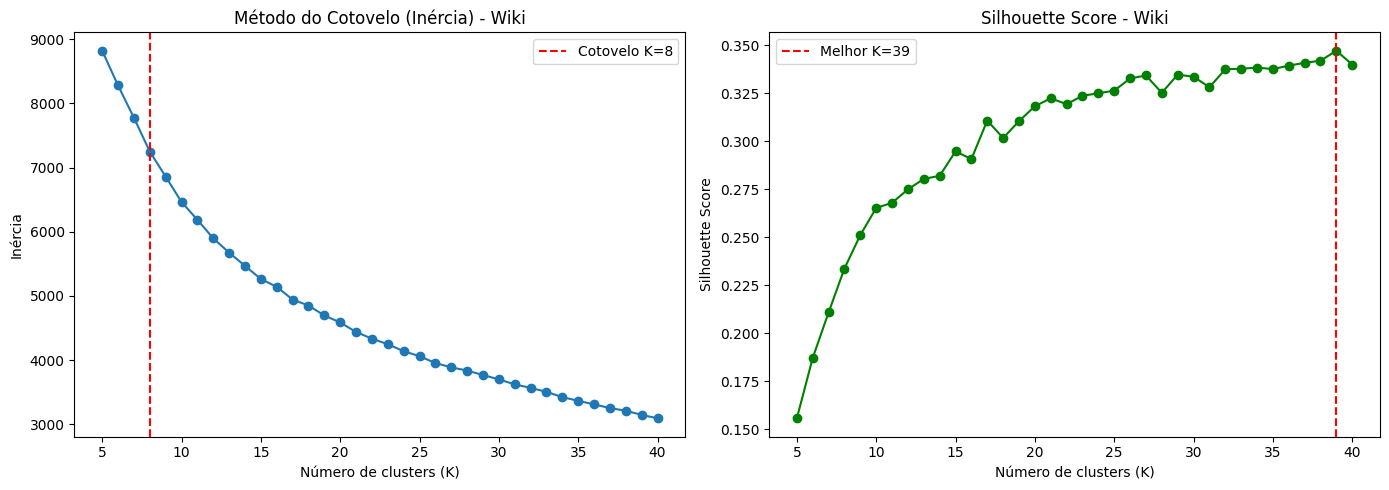

K sugerido pelo cotovelo:         8
K sugerido pelo Silhouette Score: 39


In [ ]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(5, 41)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(tfidf_reduzido_wiki)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(tfidf_reduzido_wiki, labels, sample_size=2000, random_state=42))

deltas = [inertias[i] - inertias[i+1] for i in range(len(inertias)-1)]
accel  = [deltas[i] - deltas[i+1] for i in range(len(deltas)-1)]
elbow_k = list(k_range)[accel.index(max(accel)) + 1]

best_silhouette_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].axvline(elbow_k, color="red", linestyle="--", label=f"Cotovelo K={elbow_k}")
axes[0].set_title("Método do Cotovelo (Inércia) - Wiki")
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inércia")
axes[0].legend()

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="green")
axes[1].axvline(best_silhouette_k, color="red", linestyle="--", label=f"Melhor K={best_silhouette_k}")
axes[1].set_title("Silhouette Score - Wiki")
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"K sugerido pelo cotovelo:         {elbow_k}")
print(f"K sugerido pelo Silhouette Score: {best_silhouette_k}")

In [ ]:
df_clusters_wiki = pd.DataFrame({
    'arquivo': nomes_filtrados_wiki
})

n_clusters_wiki = best_silhouette_k
km_tfidf_wiki = KMeans(n_clusters=n_clusters_wiki, random_state=42, n_init=10)
df_clusters_wiki['cluster_lexico'] = km_tfidf_wiki.fit_predict(tfidf_reduzido_wiki)

print(f"Usando K={n_clusters_wiki} (silhouette) — distribuição léxica (Wiki):")
print(df_clusters_wiki['cluster_lexico'].value_counts())

Nova distribuição léxica (Wiki):
cluster_lexico
34    949
5     844
11    642
6     638
8     629
15    596
29    576
10    574
3     553
2     458
31    449
26    441
33    413
24    383
23    374
9     351
37    351
38    350
36    335
18    331
12    315
19    301
4     286
22    271
30    263
13    260
1     255
20    245
16    236
32    197
7     183
14    182
21    167
17    162
35    160
0     157
25    152
28    106
27    100
Name: count, dtype: int64


In [ ]:
print(f"\nCalculando métricas de separação para {n_clusters_wiki} clusters (Wiki)...")

dist_matrix_global_wiki = pairwise_distances(tfidf_reduzido_wiki, metric='euclidean')

analise_clusters_dinamico_wiki = []

for i in range(len(tfidf_reduzido_wiki)):
    cluster_atual = df_clusters_wiki.loc[i, 'cluster_lexico']

    idx_intra = df_clusters_wiki[df_clusters_wiki['cluster_lexico'] == cluster_atual].index
    idx_extra = df_clusters_wiki[df_clusters_wiki['cluster_lexico'] != cluster_atual].index

    dist_intra = dist_matrix_global_wiki[i, idx_intra]
    dist_intra_mean = dist_intra[dist_intra > 0].mean() if len(dist_intra) > 1 else 0

    dist_extra_mean = dist_matrix_global_wiki[i, idx_extra].mean() if len(idx_extra) > 0 else 0

    score_separacao = dist_extra_mean - dist_intra_mean

    analise_clusters_dinamico_wiki.append({
        'arquivo': nomes_filtrados_wiki[i],
        'texto': textos_filtrados_wiki[i],
        'cluster_principal': cluster_atual,
        'dist_intra_media': dist_intra_mean,
        'dist_extra_media': dist_extra_mean,
        'score_separacao': score_separacao
    })

df_analise_final_wiki = pd.DataFrame(analise_clusters_dinamico_wiki)

df_analise_final_wiki.to_csv('analise_separacao_wiki.csv', index=False, encoding='utf-8-sig')
print("Análise de separação Wiki concluída e salva.")


Calculando métricas de separação para 39 clusters (Wiki)...
Análise de separação Wiki concluída e salva.


In [ ]:
tsne_wiki = TSNE(n_components=2, random_state=42)
pontos_2d_wiki = tsne_wiki.fit_transform(tfidf_reduzido_wiki)

df_analise_final_wiki['tsne_x'] = pontos_2d_wiki[:, 0]
df_analise_final_wiki['tsne_y'] = pontos_2d_wiki[:, 1]

print("Coordenadas t-SNE (Wiki) sincronizadas com o DataFrame com sucesso.")

Coordenadas t-SNE (Wiki) sincronizadas com o DataFrame com sucesso.


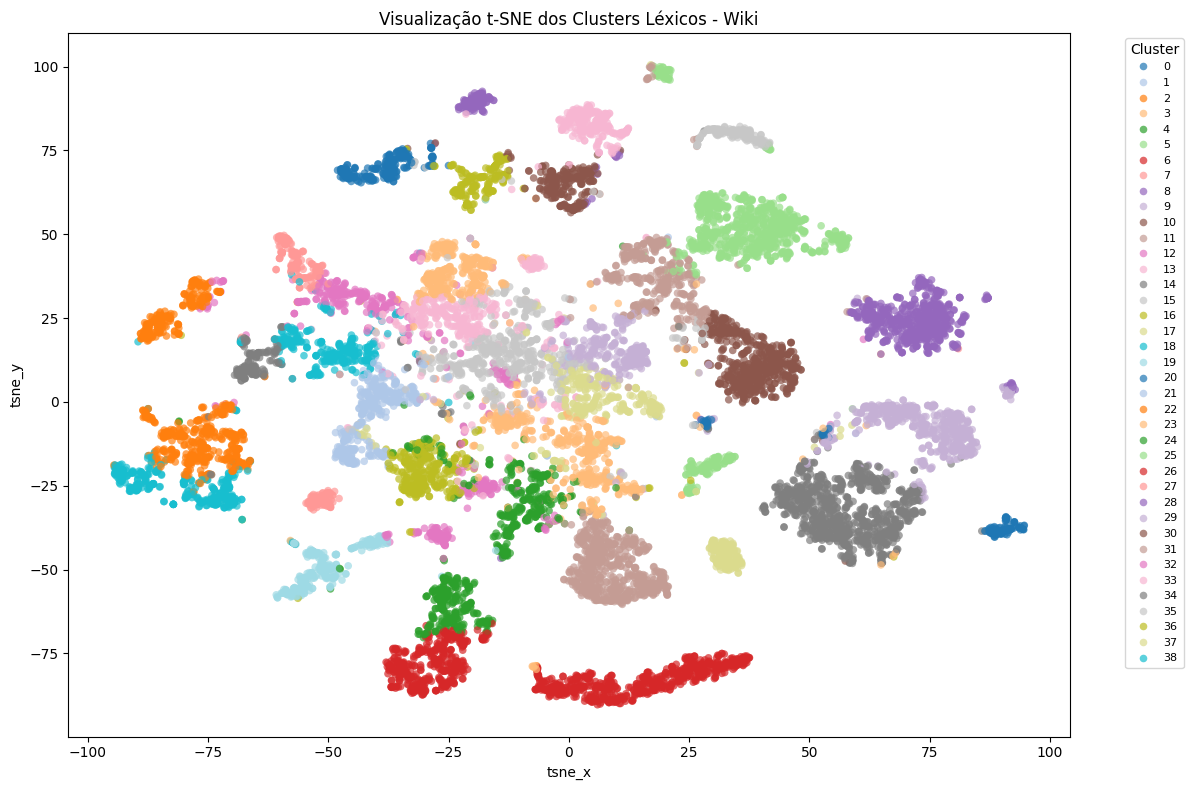

In [ ]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_analise_final_wiki,
    x="tsne_x",
    y="tsne_y",
    hue="cluster_principal",
    palette="tab20",
    s=30,
    alpha=0.7,
    linewidth=0
)

plt.title("Visualização t-SNE dos Clusters Léxicos - Wiki")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
def selecionar_e_separar_documentos_wiki(df_analise, arquivo_jsonl_original,
                                     linhas_originais, total_selecionar=1000):
    metadados_selecao_local = []
    documentos_selecionados = set()

    tamanhos_clusters = df_analise['cluster_principal'].value_counts()
    proporcoes        = tamanhos_clusters / len(df_analise)
    alocacao          = (proporcoes * total_selecionar).round().astype(int)

    diferenca = total_selecionar - alocacao.sum()
    if diferenca != 0:
        for cluster in tamanhos_clusters.index[:abs(diferenca)]:
            alocacao[cluster] += 1 if diferenca > 0 else -1

    dist_intra_media_global = df_analise.groupby('cluster_principal')['dist_intra_media'].mean().mean()

    for cluster_id, cota in alocacao.items():
        df_cluster = df_analise[
            df_analise['cluster_principal'] == cluster_id
        ].sort_values('score_separacao')

        dist_intra_cluster = df_cluster['dist_intra_media'].mean()
        is_cluster_ambiguo = dist_intra_cluster > dist_intra_media_global
        n_ambiguos = int(cota * 0.70) if is_cluster_ambiguo else cota // 2
        n_coesos   = cota - n_ambiguos

        for _, row in df_cluster.head(n_ambiguos).iterrows():
            documentos_selecionados.add(row['arquivo'])
            metadados_selecao_local.append({
                'arquivo': row['arquivo'],
                'cluster': int(cluster_id),
                'tipo'   : 'Ambíguo',
                'score'  : row['score_separacao'],
                'x'      : row['tsne_x'],
                'y'      : row['tsne_y']
            })

        for _, row in df_cluster.tail(n_coesos).iterrows():
            documentos_selecionados.add(row['arquivo'])
            metadados_selecao_local.append({
                'arquivo': row['arquivo'],
                'cluster': int(cluster_id),
                'tipo'   : 'Coeso',
                'score'  : row['score_separacao'],
                'x'      : row['tsne_x'],
                'y'      : row['tsne_y']
            })

    nome_base  = os.path.basename(arquivo_jsonl_original).replace('.jsonl', '')
    caminho_dir = os.path.dirname(os.path.abspath(arquivo_jsonl_original))
    generation_file = os.path.join(caminho_dir, f"generation_{nome_base}_CPS.jsonl")
    assignment_file = os.path.join(caminho_dir, f"assignment_{nome_base}_CPS.jsonl")

    with open(generation_file, 'w', encoding='utf-8') as f_gen, \
         open(assignment_file, 'w', encoding='utf-8') as f_ass:

        for doc_id, linha_bruta in linhas_originais.items():
            if doc_id in documentos_selecionados:
                f_gen.write(linha_bruta)
            else:
                f_ass.write(linha_bruta)

    print(f"generation → {generation_file}")
    print(f"assignment → {assignment_file}")
    print("Separação concluída!")

    df_plot = pd.DataFrame(metadados_selecao_local)
    fig = px.histogram(
        df_plot,
        x='cluster',
        color='tipo',
        barmode='group',
        title='Distribuição de Documentos Selecionados (Geração) por Cluster - Wiki',
        labels={'cluster': 'ID do Cluster', 'count': 'Qtd. de Documentos Selecionados'},
        color_discrete_map={'Ambíguo': '#EF553B', 'Coeso': '#00CC96'}
    )
    fig.update_layout(xaxis_type='category')
    fig.show()
    return metadados_selecao_local

In [ ]:
import json
import os

generation_file_wiki = 'generation_wiki_CPS.jsonl'

total_selecionar_wiki = calcular_total_selecionar(len(df_analise_final_wiki))
metadados_selecao_wiki = selecionar_e_separar_documentos_wiki(df_analise_final_wiki, target_file_wiki, linhas_originais_wiki, total_selecionar=total_selecionar_wiki)

print(f"Verificando arquivo: {generation_file_wiki}")

docs_no_jsonl = {}
with open(generation_file_wiki, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line.strip())
        h = hash_texto_wiki(data['text'])
        docs_no_jsonl[h] = data['text'].strip()

print(f"Documentos encontrados no JSONL: {len(docs_no_jsonl)}")

total_sel_wiki = calcular_total_selecionar(len(df_analise_final_wiki))
tamanhos_clusters = df_analise_final_wiki['cluster_principal'].value_counts()
proporcoes = tamanhos_clusters / len(df_analise_final_wiki)
alocacao = (proporcoes * total_sel_wiki).round().astype(int)

diferenca = total_sel_wiki - alocacao.sum()
if diferenca != 0:
    for cluster in tamanhos_clusters.index[:abs(diferenca)]:
        alocacao[cluster] += 1 if diferenca > 0 else -1

dist_intra_media_global = df_analise_final_wiki.groupby('cluster_principal')['dist_intra_media'].mean().mean()

erros = []
sucessos = 0

for cluster_id, cota in alocacao.items():
    df_cluster = df_analise_final_wiki[df_analise_final_wiki['cluster_principal'] == cluster_id].sort_values('score_separacao')

    dist_intra_cluster = df_cluster['dist_intra_media'].mean()
    is_cluster_ambiguo = dist_intra_cluster > dist_intra_media_global
    n_ambiguos = int(cota * 0.70) if is_cluster_ambiguo else cota // 2
    n_coesos   = cota - n_ambiguos

    esperados = pd.concat([df_cluster.head(n_ambiguos), df_cluster.tail(n_coesos)])

    for _, row in esperados.iterrows():
        doc_id = row['arquivo']
        texto_df = row['texto'].strip()

        if doc_id not in docs_no_jsonl:
            erros.append(f"Erro: Documento {doc_id} do cluster {cluster_id} não encontrado no JSONL.")
        else:
            if docs_no_jsonl[doc_id] != texto_df:
                erros.append(f"Erro: Conteúdo divergente para o documento {doc_id}.")
            else:
                sucessos += 1

if not erros:
    print(f"\n✅ Sucesso! Todos os {sucessos} documentos esperados (ambíguos/coesos) estão presentes e corretos no arquivo JSONL.")
else:
    print(f"\n❌ Foram encontrados {len(erros)} erros na verificação.")

Seleção probabilística  →  N=14,235 | n_d=142 | K_u=100 | n_s=1,020 | p*≈0.0003
generation → /content/generation_wiki_CPS.jsonl
assignment → /content/assignment_wiki_CPS.jsonl
Separação concluída!


Verificando arquivo: generation_wiki_CPS.jsonl
Documentos encontrados no JSONL: 1020
Seleção probabilística  →  N=14,235 | n_d=142 | K_u=100 | n_s=1,020 | p*≈0.0003

✅ Sucesso! Todos os 1020 documentos esperados (ambíguos/coesos) estão presentes e corretos no arquivo JSONL.


In [ ]:
def executar_selecao_e_plot_wiki(df_analise, total_selecionar, cluster_id):
    tamanhos_clusters = df_analise['cluster_principal'].value_counts()
    alocacao = (tamanhos_clusters / len(df_analise) * total_selecionar).round().astype(int)

    dif = total_selecionar - alocacao.sum()
    if dif != 0:
        for cl in tamanhos_clusters.index[:abs(dif)]:
            alocacao[cl] += 1 if dif > 0 else -1

    dist_intra_media_global = df_analise.groupby('cluster_principal')['dist_intra_media'].mean().mean()

    metadados_selecao = []

    for cid, cota in alocacao.items():
        df_c = df_analise[df_analise['cluster_principal'] == cid].sort_values('score_separacao')

        dist_intra_cluster = df_c['dist_intra_media'].mean()
        is_cluster_ambiguo = dist_intra_cluster > dist_intra_media_global
        n_amb = int(cota * 0.7) if is_cluster_ambiguo else cota // 2
        n_coe = cota - n_amb

        n_amb = min(n_amb, len(df_c))
        n_coe = min(n_coe, len(df_c) - n_amb)

        for tipo, subset in [('Ambíguo', df_c.head(n_amb)), ('Coeso', df_c.tail(n_coe))]:
            for _, row in subset.iterrows():
                metadados_selecao.append({
                    'arquivo': row['arquivo'],
                    'cluster': int(cid),
                    'tipo': tipo,
                    'x': row['tsne_x'],
                    'y': row['tsne_y'],
                    'score': row['score_separacao']
                })

    selecionados_cluster = [m for m in metadados_selecao if m['cluster'] == cluster_id]
    amb_pts = [m for m in selecionados_cluster if m['tipo'] == 'Ambíguo']
    coe_pts = [m for m in selecionados_cluster if m['tipo'] == 'Coeso']

    print(f"Cluster {cluster_id}  |  Ambíguos: {len(amb_pts)}  |  Coesos: {len(coe_pts)}")
    if not selecionados_cluster:
        print("Nenhum documento selecionado para este cluster.")
        return

    ids_selecionados = {m['arquivo'] for m in selecionados_cluster}
    membros = df_analise[df_analise['cluster_principal'] == cluster_id]
    nao_sel = membros[~membros['arquivo'].isin(ids_selecionados)]

    pad_x = (membros['tsne_x'].max() - membros['tsne_x'].min()) * 0.08 or 1
    pad_y = (membros['tsne_y'].max() - membros['tsne_y'].min()) * 0.08 or 1
    x_range = [membros['tsne_x'].min() - pad_x, membros['tsne_x'].max() + pad_x]
    y_range = [membros['tsne_y'].min() - pad_y, membros['tsne_y'].max() + pad_y]

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=nao_sel['tsne_x'], y=nao_sel['tsne_y'],
        mode='markers',
        marker=dict(symbol='circle', size=8, color='orange', opacity=0.5,
                    line=dict(width=0.5, color='darkorange')),
        name=f'Membros não selecionados (n={len(nao_sel)})',
        text=nao_sel['arquivo'],
        hovertemplate='<b>%{text}</b><extra>Membro</extra>'
    ))

    if coe_pts:
        fig.add_trace(go.Scatter(
            x=[p['x'] for p in coe_pts],
            y=[p['y'] for p in coe_pts],
            mode='markers',
            marker=dict(symbol='triangle-up', size=16, color='royalblue',
                        line=dict(width=1.5, color='white')),
            name=f'▲ Coeso (n={len(coe_pts)})',
            text=[p['arquivo'] for p in coe_pts],
            customdata=[round(p['score'], 4) for p in coe_pts],
            hovertemplate='<b>%{text}</b><br>score: %{customdata}<extra>Coeso</extra>'
        ))

    if amb_pts:
        fig.add_trace(go.Scatter(
            x=[p['x'] for p in amb_pts],
            y=[p['y'] for p in amb_pts],
            mode='markers',
            marker=dict(symbol='triangle-down', size=16, color='crimson',
                        line=dict(width=1.5, color='white')),
            name=f'▼ Ambíguo (n={len(amb_pts)})',
            text=[p['arquivo'] for p in amb_pts],
            customdata=[round(p['score'], 4) for p in amb_pts],
            hovertemplate='<b>%{text}</b><br>score: %{customdata}<extra>Ambíguo</extra>'
        ))

    fig.update_layout(
        title=dict(
            text=f'Cluster {cluster_id} (Wiki) — {len(selecionados_cluster)} selecionados '
                 f'(▲ {len(coe_pts)} Coesos | ▼ {len(amb_pts)} Ambíguos)',
            font=dict(size=15)
        ),
        xaxis=dict(range=x_range, title='t-SNE x', showgrid=True, gridcolor='#eee'),
        yaxis=dict(range=y_range, title='t-SNE y', showgrid=True, gridcolor='#eee'),
        template='plotly_white',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
        height=700,
        margin=dict(l=40, r=40, t=80, b=40)
    )
    fig.show()

In [ ]:
total_selecionar_wiki = calcular_total_selecionar(len(df_analise_final_wiki))

Seleção probabilística  →  N=14,235 | n_d=142 | K_u=100 | n_s=1,020 | p*≈0.0003


In [ ]:
executar_selecao_e_plot_wiki(df_analise_final_wiki, total_selecionar_wiki, cluster_id=5)

Cluster 5  |  Ambíguos: 30  |  Coesos: 30


In [ ]:
generation_file_wiki = 'generation_wiki_CPS.jsonl'

hashes_generation_wiki = {}
with open(generation_file_wiki, 'r', encoding='utf-8') as f:
    for line in f:
        d = json.loads(line.strip())
        texto = d.get('text', '')
        if texto.strip():
            h = hash_texto_wiki(texto)
            hashes_generation_wiki[h] = texto

print(f"Documentos em generation (Wiki): {len(hashes_generation_wiki)}\n")

dist_intra_media_global_wiki = df_analise_final_wiki.groupby('cluster_principal')['dist_intra_media'].mean().mean()
tamanhos_clusters_wiki = df_analise_final_wiki['cluster_principal'].value_counts()
total_sel_wiki = calcular_total_selecionar(len(df_analise_final_wiki))

alocacao_wiki = (tamanhos_clusters_wiki / len(df_analise_final_wiki) * total_sel_wiki).round().astype(int)
dif = total_sel_wiki - alocacao_wiki.sum()
if dif != 0:
    alocacao_wiki[alocacao_wiki.index[0]] += dif

print(f"{'Cluster':>8} | {'Tam':>5} | {'Amb':>4} | {'Coe':>4} | {'Amb OK':>8} | {'Coe OK':>8} | {'Ausentes'}")
print("=" * 80)

erros_totais_wiki = []

for cluster_id in sorted(df_analise_final_wiki['cluster_principal'].unique()):
    df_c = df_analise_final_wiki[
        df_analise_final_wiki['cluster_principal'] == cluster_id
    ].sort_values('score_separacao')

    cota = alocacao_wiki.get(cluster_id, 0)
    dist_intra_cluster = df_c['dist_intra_media'].mean()
    is_ambiguo = dist_intra_cluster > dist_intra_media_global_wiki
    n_amb = int(cota * 0.70) if is_ambiguo else cota // 2
    n_coe = cota - n_amb

    esperados_amb = set(df_c.head(n_amb)['arquivo'])
    esperados_coe = set(df_c.tail(n_coe)['arquivo'])
    presentes     = set(hashes_generation_wiki.keys())

    ausentes_amb = esperados_amb - presentes
    ausentes_coe = esperados_coe - presentes

    amb_ok = len(ausentes_amb) == 0
    coe_ok = len(ausentes_coe) == 0

    ausentes = list(ausentes_amb | ausentes_coe)
    ausentes_str = str(ausentes[:2])[1:-1] + ("..." if len(ausentes) > 2 else "") if ausentes else "—"

    status_amb = "✅" if amb_ok else f"❌({len(ausentes_amb)})"
    status_coe = "✅" if coe_ok else f"❌({len(ausentes_coe)})"

    print(f"{cluster_id:>8} | {len(df_c):>5} | {n_amb:>4} | {n_coe:>4} | {status_amb:>8} | {status_coe:>8} | {ausentes_str}")

    if not amb_ok or not coe_ok:
        erros_totais_wiki.append(cluster_id)

print("=" * 80)
if not erros_totais_wiki:
    print(f"\n✅ Verificação completa: todos os {total_sel_wiki} documentos selecionados estão corretamente presentes em {generation_file_wiki}")
else:
    print(f"\n❌ Clusters com documentos ausentes: {erros_totais_wiki}")

Documentos em generation (Wiki): 1020

Seleção probabilística  →  N=14,235 | n_d=142 | K_u=100 | n_s=1,020 | p*≈0.0003
 Cluster |   Tam |  Amb |  Coe |   Amb OK |   Coe OK | Ausentes
       0 |   157 |    7 |    4 |        ✅ |        ✅ | —
       1 |   255 |   12 |    6 |        ✅ |        ✅ | —
       2 |   458 |   16 |   17 |        ✅ |        ✅ | —
       3 |   553 |   28 |   12 |        ✅ |        ✅ | —
       4 |   286 |   10 |   10 |        ✅ |        ✅ | —
       5 |   844 |   30 |   30 |        ✅ |        ✅ | —
       6 |   638 |   23 |   23 |        ✅ |        ✅ | —
       7 |   183 |    6 |    7 |        ✅ |        ✅ | —
       8 |   629 |   22 |   23 |        ✅ |        ✅ | —
       9 |   351 |   17 |    8 |        ✅ |        ✅ | —
      10 |   574 |   20 |   21 |        ✅ |        ✅ | —
      11 |   642 |   23 |   23 |        ✅ |        ✅ | —
      12 |   315 |   16 |    7 |        ✅ |        ✅ | —
      13 |   260 |    9 |   10 |        ✅ |        ✅ | —
      14 |   182 | 

In [ ]:
import random
import json
import os
import pandas as pd

def load_jsonl_wiki(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]

gen_wiki_orig = load_jsonl_wiki('generation_wiki_CPS.jsonl')
asgn_wiki_orig = load_jsonl_wiki('assignment_wiki_CPS.jsonl')
all_wiki_data = gen_wiki_orig + asgn_wiki_orig

print(f"Total de instâncias Wiki: {len(all_wiki_data)}")

N_GENERATION_WIKI = 1020
SEEDS = [42, 123, 7]

set_gen_original = {hash_texto_wiki(d['text']) for d in gen_wiki_orig}

results_comparison = []

for i, seed in enumerate(SEEDS, start=1):
    random.seed(seed)
    shuffled = all_wiki_data.copy()
    random.shuffle(shuffled)

    gen_split = shuffled[:N_GENERATION_WIKI]
    asgn_split = shuffled[N_GENERATION_WIKI:]

    gen_path = f'generation_wiki_random{i}.jsonl'
    asgn_path = f'assignment_wiki_random{i}.jsonl'

    with open(gen_path, 'w', encoding='utf-8') as f:
        for obj in gen_split:
            f.write(json.dumps(obj, ensure_ascii=False) + '\n')

    with open(asgn_path, 'w', encoding='utf-8') as f:
        for obj in asgn_split:
            f.write(json.dumps(obj, ensure_ascii=False) + '\n')

    set_gen_random = {hash_texto_wiki(d['text']) for d in gen_split}
    overlap = len(set_gen_random.intersection(set_gen_original))

    results_comparison.append({
        'Split': f'Random {i}',
        'Seed': seed,
        'Overlap com Original (CPS) (Docs)': overlap,
        '% de Similaridade': (overlap / N_GENERATION_WIKI) * 100
    })

print("\n--- Comparação de Splits Aleatórios vs Original (CPS) ---")
df_comp = pd.DataFrame(results_comparison)
display(df_comp)

print("\nArquivos gerados com sucesso.")

Total de instâncias Wiki: 14235

--- Comparação de Splits Aleatórios vs Original (CPS) ---


,Split,Seed,Overlap com Original (CPS) (Docs),% de Similaridade
0,Random 1,42,67,6.568627
1,Random 2,123,80,7.843137
2,Random 3,7,80,7.843137



Arquivos gerados com sucesso.


# ***Bills***

***Conhecendo e processando o dataset***

In [ ]:
from datasets import load_dataset
bills = load_dataset('zli12321/Bills')

In [ ]:
bills

DatasetDict({
    train: Dataset({
        features: ['id', 'summary', 'topic', 'subtopic', 'subjects_top_term', 'date', 'text'],
        num_rows: 32661
    })
    test: Dataset({
        features: ['id', 'summary', 'topic', 'subtopic', 'subjects_top_term', 'date', 'text'],
        num_rows: 15242
    })
})

In [ ]:
for split in bills.keys():
    df_tmp = bills[split].to_pandas()
    print(f"Split: {split}, Shape: {df_tmp.shape}")
    print(f"Colunas: {list(df_tmp.columns)}")
    print(df_tmp.head(2))
    print()

Split: train, Shape: (32661, 7)
Colunas: ['id', 'summary', 'topic', 'subtopic', 'subjects_top_term', 'date', 'text']
           id                                            summary   topic  \
0    110-HR-4  Medicare Prescription Drug Price Negotiation A...  Health   
1  110-HR-118  Amends part D (Voluntary Prescription Drug Ben...  Health   

                 subtopic subjects_top_term        date  \
0  Drug Coverage and Cost            Health  2007-01-05   
1  Drug Coverage and Cost            Health  2007-01-04   

                                                text  
0  medicare prescription drug price negotiation a...  
1  amends voluntary prescription drug benefit pro...  

Split: test, Shape: (15242, 7)
Colunas: ['id', 'summary', 'topic', 'subtopic', 'subjects_top_term', 'date', 'text']
         id                                            summary    topic  \
0  110-HR-1  Implementing Recommendations of the 9/11 Commi...  Defense   
1  110-HR-6  Energy Independence and Securit

In [ ]:
cols_to_analyze_bills = ['topic', 'subtopic']
stats_bills = []

print("--- Análise de Hierarquia por Split (Bills) ---")
for split in bills.keys():
    df_split = bills[split].to_pandas()
    row_data = {'Split': split, 'Instâncias': len(df_split)}

    for col in cols_to_analyze_bills:
        if col in df_split.columns:
            row_data[f'Qtd {col}'] = df_split[col].nunique()
    stats_bills.append(row_data)

display(pd.DataFrame(stats_bills))

print("\n--- Sobreposição de Rótulos (Intersection) ---")
splits_bills = list(bills.keys())
if len(splits_bills) >= 2:
    s1, s2 = splits_bills[0], splits_bills[1]
    df1 = bills[s1].to_pandas()
    df2 = bills[s2].to_pandas()

    for col in cols_to_analyze_bills:
        if col in df1.columns and col in df2.columns:
            set1 = set(df1[col].unique())
            set2 = set(df2[col].unique())
            comum = set1.intersection(set2)
            print(f"Coluna '{col}': {len(comum)} rótulos em comum entre {s1} e {s2}")

--- Análise de Hierarquia por Split (Bills) ---


,Split,Instâncias,Qtd topic,Qtd subtopic
0,train,32661,21,114
1,test,15242,19,56



--- Sobreposição de Rótulos (Intersection) ---
Coluna 'topic': 19 rótulos em comum entre train e test
Coluna 'subtopic': 7 rótulos em comum entre train e test


In [ ]:
df_train_bills = bills['train'].to_pandas()
df_train_bills.to_csv('bills_train.csv', index=False, encoding='utf-8-sig')

print(f"Arquivo 'bills_train.csv' gerado com sucesso! Total de {len(df_train_bills)} instâncias.")

Arquivo 'bills_train.csv' gerado com sucesso! Total de 32661 instâncias.


In [ ]:
# Filtragem do dataset Bills:
#   1. Texto sem tópico → excluir
#   2. Mesmo texto, mesmo tópico → manter só um exemplar
#   3. Mesmo texto, tópicos diferentes → excluir TODOS

print(f"Instâncias originais: {len(df_train_bills)}")
print(f"Textos únicos: {df_train_bills['text'].nunique()}")
print()

sem_topico = df_train_bills[df_train_bills['topic'].isna() | (df_train_bills['topic'].str.strip() == '')]
print(f"[Regra 1] Textos sem tópico: {len(sem_topico)} — excluídos")
df_train_bills = df_train_bills[~df_train_bills.index.isin(sem_topico.index)]

topics_por_texto = df_train_bills.groupby('text')['topic'].nunique()
textos_multi_topico = set(topics_por_texto[topics_por_texto > 1].index)

excluidos_multi = df_train_bills[df_train_bills['text'].isin(textos_multi_topico)]
print(f"\n[Regra 3] Textos com tópicos conflitantes: {len(textos_multi_topico)} textos únicos ({len(excluidos_multi)} instâncias) — excluídos")
print("="*80)

for texto in sorted(textos_multi_topico):
    rows = excluidos_multi[excluidos_multi['text'] == texto]
    topicos = rows['topic'].unique().tolist()
    preview = texto[:120].replace('\n', ' ') + ('...' if len(texto) > 120 else '')
    print(f"\nTexto: \"{preview}\"")
    print(f"  Tópicos atribuídos: {topicos}")
    print(f"  Motivo: tópicos conflitantes → todas as {len(rows)} instâncias excluídas")

print("="*80)

df_train_bills = df_train_bills[~df_train_bills['text'].isin(textos_multi_topico)]

duplicatas_exatas = df_train_bills[df_train_bills.duplicated(subset='text', keep='first')]
print(f"\n[Regra 2] Duplicatas exatas (mesmo texto, mesmo tópico): {len(duplicatas_exatas)} instâncias — excluídos (mantido 1 exemplar cada)")
df_train_bills = df_train_bills.drop_duplicates(subset='text', keep='first')

print(f"\n--- Resultado final ---")
print(f"Instâncias restantes: {len(df_train_bills)}")
df_train_bills = df_train_bills.reset_index(drop=True)

Instâncias originais: 32661
Textos únicos: 26733

[Regra 1] Textos sem tópico: 0 — excluídos

[Regra 3] Textos com tópicos conflitantes: 705 textos únicos (1785 instâncias) — excluídos

Texto: "21st century bill establishes 21st century conservation service corps provides work training opportunities youth veteran..."
  Tópicos atribuídos: ['Public Lands', 'Labor']
  Motivo: tópicos conflitantes → todas as 2 instâncias excluídas

Texto: "21st century investment act amends internal revenue code permanent tax credit increasing research activities allow incre..."
  Tópicos atribuídos: ['Macroeconomics', 'Technology']
  Motivo: tópicos conflitantes → todas as 2 instâncias excluídas

Texto: "21st secretary energy consultation 21st century energy deployment corporation established act develop publish near- medi..."
  Tópicos atribuídos: ['Macroeconomics', 'Energy']
  Motivo: tópicos conflitantes → todas as 2 instâncias excluídas

Texto: "access appropriate immunizations veterans act includes 

In [ ]:
df_train_bills.head()

,id,summary,topic,subtopic,subjects_top_term,date,text
0,110-HR-4,Medicare Prescription Drug Price Negotiation A...,Health,Drug Coverage and Cost,Health,2007-01-05,medicare prescription drug price negotiation a...
1,110-HR-118,Amends part D (Voluntary Prescription Drug Ben...,Health,Drug Coverage and Cost,Health,2007-01-04,amends voluntary prescription drug benefit pro...
2,110-HR-205,Medicare Prescription Drug Enrollment Extensio...,Health,Drug Coverage and Cost,Health,2007-01-04,amends title xviii medicare social security ac...
3,110-HR-426,Medicaid Obesity Treatment Act of 2007 - Amend...,Health,Drug Coverage and Cost,Health,2007-01-11,treatment act amends title xix medicaid social...
4,110-HR-464,Compassionate Assistance for Rape Emergencies ...,Health,Drug Coverage and Cost,Health,2007-01-12,compassionate assistance rape emergencies act ...


In [ ]:
bills_jsonl_path = 'bills.jsonl'
df_train_bills.to_json(bills_jsonl_path, orient='records', lines=True, force_ascii=False)

print(f"Arquivo '{bills_jsonl_path}' gerado com sucesso!")

Arquivo 'bills.jsonl' gerado com sucesso!


In [ ]:
hierarquia_train_bills = df_train_bills.groupby('topic')['subtopic'].unique().to_dict()

print("--- Tópicos e Subtópicos no Split de Treino (Bills) ---")
for topic, subtopics in hierarquia_train_bills.items():
    print(f"\nTópico: {topic}")
    for sub in sorted(subtopics):
        print(f"  - {sub}")

--- Tópicos e Subtópicos no Split de Treino (Bills) ---

Tópico: Agriculture
  - Animal and Crop Disease
  - Fisheries & Fishing
  - Food Inspection & Safety
  - Marketing & Promotion
  - R&D
  - Subsidies to Farmers

Tópico: Civil Rights
  - Age Discrimination
  - Anti-Government
  - Drug Industry
  - Freedom of Speech
  - Gender Discrimination
  - Postal Service
  - Right to Privacy

Tópico: Culture
  - General

Tópico: Defense
  - Alliances
  - Civilian Personnel
  - Claims against Military
  - Contractors
  - Foreign Operations
  - Hazardous Waste
  - Installations & Land
  - Intelligence
  - Nuclear Arms
  - Personnel Issues
  - R&D
  - Readiness
  - Reserve Forces

Tópico: Domestic Commerce
  - Banking
  - Consumer Finance
  - Consumer Safety
  - Corporate Management
  - Insurance Regulation
  - Small Businesses
  - Sports Regulation
  - Tourism

Tópico: Education
  - Elementary & Secondary
  - Higher
  - R&D
  - Reserve Forces
  - Special
  - Underprivileged
  - Vocational

Tópi

***Método CPS***

In [ ]:
import json
import hashlib

def hash_texto_bills(texto: str) -> str:
    return "bills_" + hashlib.sha256(texto.strip().encode("utf-8")).hexdigest()[:16]

target_file_bills = 'bills.jsonl'
textos_bills = []
nomes_arquivos_bills = []
linhas_originais_bills = {}

print(f"Carregando textos do arquivo {target_file_bills}...")

with open(target_file_bills, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        try:
            data = json.loads(line.strip())

            if not data.get('topic'):
                continue

            if 'text' in data and data['text'].strip():
                texto = data['text']
                doc_id = hash_texto_bills(texto)

                if doc_id in linhas_originais_bills:
                    continue

                textos_bills.append(texto)
                nomes_arquivos_bills.append(doc_id)
                linhas_originais_bills[doc_id] = line
        except json.JSONDecodeError as e:
            print(f"Erro na linha {i+1}: {e}")

print(f"Total de {len(textos_bills)} textos carregados dos Bills.")

Carregando textos do arquivo bills.jsonl...
Total de 26028 textos carregados dos Bills.


In [ ]:
MIN_TOKENS = 5

textos_filtrados_bills = []
nomes_filtrados_bills = []
documentos_removidos_bills = []

for texto, nome in zip(textos_bills, nomes_arquivos_bills):
    tokens = [t for t in texto.split() if len(t) >= 3]
    if len(tokens) >= MIN_TOKENS:
        textos_filtrados_bills.append(texto)
        nomes_filtrados_bills.append(nome)
    else:
        documentos_removidos_bills.append({'arquivo': nome, 'n_tokens': len(tokens)})

print(f"Textos Bills originais     : {len(textos_bills)}")
print(f"Textos Bills após filtragem: {len(textos_filtrados_bills)}")
print(f"Removidos (muito curtos)   : {len(documentos_removidos_bills)}")

Textos Bills originais     : 26028
Textos Bills após filtragem: 26028
Removidos (muito curtos)   : 0


In [ ]:
vectorizer_bills = TfidfVectorizer(max_features=1000, stop_words=stop_words_multilingue, ngram_range=(1, 2), token_pattern=r'(?u)\b[a-zA-Záàâãéèêíïóôõöúç]{3,}\b')
tfidf_matrix_bills = vectorizer_bills.fit_transform(textos_filtrados_bills)

svd_bills = TruncatedSVD(n_components=50, random_state=42)
normalizer_bills = Normalizer(copy=False)
lsa_bills = make_pipeline(svd_bills, normalizer_bills)
tfidf_reduzido_bills = lsa_bills.fit_transform(tfidf_matrix_bills)

print(f"Matriz TF-IDF dos Bills: {tfidf_matrix_bills.shape}")
print(f"Matriz reduzida (LSA): {tfidf_reduzido_bills.shape}")

Matriz TF-IDF dos Bills: (26028, 1000)
Matriz reduzida (LSA): (26028, 50)


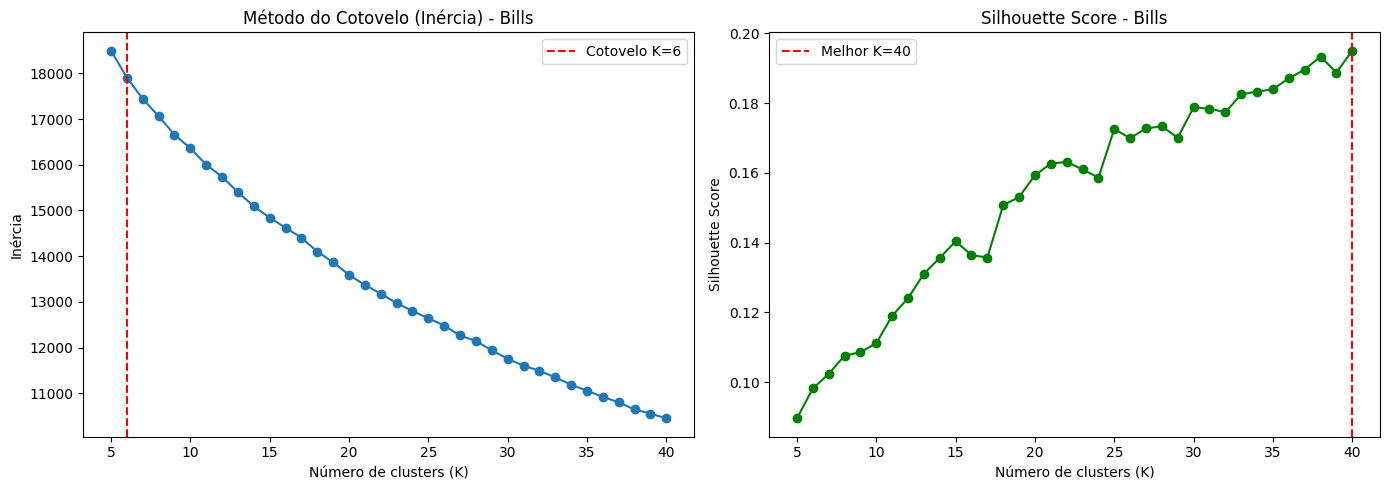

K sugerido pelo cotovelo:         6
K sugerido pelo Silhouette Score: 40


In [ ]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range_bills = range(5, 41)
inertias_bills = []
silhouette_scores_bills = []

for k in k_range_bills:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(tfidf_reduzido_bills)
    inertias_bills.append(km.inertia_)
    silhouette_scores_bills.append(silhouette_score(tfidf_reduzido_bills, labels, sample_size=2000, random_state=42))

deltas_bills = [inertias_bills[i] - inertias_bills[i+1] for i in range(len(inertias_bills)-1)]
accel_bills  = [deltas_bills[i] - deltas_bills[i+1] for i in range(len(deltas_bills)-1)]
elbow_k_bills = list(k_range_bills)[accel_bills.index(max(accel_bills)) + 1]

best_silhouette_k_bills = list(k_range_bills)[silhouette_scores_bills.index(max(silhouette_scores_bills))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range_bills), inertias_bills, marker="o")
axes[0].axvline(elbow_k_bills, color="red", linestyle="--", label=f"Cotovelo K={elbow_k_bills}")
axes[0].set_title("Método do Cotovelo (Inércia) - Bills")
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inércia")
axes[0].legend()

axes[1].plot(list(k_range_bills), silhouette_scores_bills, marker="o", color="green")
axes[1].axvline(best_silhouette_k_bills, color="red", linestyle="--", label=f"Melhor K={best_silhouette_k_bills}")
axes[1].set_title("Silhouette Score - Bills")
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"K sugerido pelo cotovelo:         {elbow_k_bills}")
print(f"K sugerido pelo Silhouette Score: {best_silhouette_k_bills}")

In [ ]:
df_clusters_bills = pd.DataFrame({
    'arquivo': nomes_filtrados_bills
})

n_clusters_bills = best_silhouette_k_bills
km_tfidf_bills = KMeans(n_clusters=n_clusters_bills, random_state=42, n_init=10)
df_clusters_bills['cluster_lexico'] = km_tfidf_bills.fit_predict(tfidf_reduzido_bills)

print(f"Usando K={n_clusters_bills} (cotovelo)")
print("\nDistribuição léxica (Bills):")
print(df_clusters_bills['cluster_lexico'].value_counts())

Usando K=40 (cotovelo)

Distribuição léxica (Bills):
cluster_lexico
6     1070
17    1065
4      995
2      934
1      904
35     856
23     850
36     830
28     829
9      811
10     786
7      784
8      782
38     778
20     752
12     738
29     737
19     681
34     653
0      610
3      608
25     581
21     580
13     580
26     578
14     576
16     563
11     546
33     536
24     532
5      509
39     472
31     454
22     424
30     405
37     390
27     352
32     342
15     321
18     234
Name: count, dtype: int64


In [ ]:
print(f"\nCalculando métricas de separação para {n_clusters_bills} clusters (Bills)...")

dist_matrix_global_bills = pairwise_distances(tfidf_reduzido_bills, metric='euclidean')

analise_clusters_dinamico_bills = []

for i in range(len(tfidf_reduzido_bills)):
    cluster_atual = df_clusters_bills.loc[i, 'cluster_lexico']

    idx_intra = df_clusters_bills[df_clusters_bills['cluster_lexico'] == cluster_atual].index
    idx_extra = df_clusters_bills[df_clusters_bills['cluster_lexico'] != cluster_atual].index

    dist_intra = dist_matrix_global_bills[i, idx_intra]
    dist_intra_mean = dist_intra[dist_intra > 0].mean() if len(dist_intra) > 1 else 0

    dist_extra_mean = dist_matrix_global_bills[i, idx_extra].mean() if len(idx_extra) > 0 else 0

    score_separacao = dist_extra_mean - dist_intra_mean

    analise_clusters_dinamico_bills.append({
        'arquivo': nomes_filtrados_bills[i],
        'texto': textos_filtrados_bills[i],
        'cluster_principal': cluster_atual,
        'dist_intra_media': dist_intra_mean,
        'dist_extra_media': dist_extra_mean,
        'score_separacao': score_separacao
    })

df_analise_final_bills = pd.DataFrame(analise_clusters_dinamico_bills)

df_analise_final_bills.to_csv('analise_separacao_bills.csv', index=False, encoding='utf-8-sig')
print("Análise de separação Bills concluída e salva.")


Calculando métricas de separação para 40 clusters (Bills)...
Análise de separação Bills concluída e salva.


In [ ]:
tsne_bills = TSNE(n_components=2, random_state=42)
pontos_2d_bills = tsne_bills.fit_transform(tfidf_reduzido_bills)

df_analise_final_bills['tsne_x'] = pontos_2d_bills[:, 0]
df_analise_final_bills['tsne_y'] = pontos_2d_bills[:, 1]

print("Coordenadas t-SNE (Bills) sincronizadas com o DataFrame com sucesso.")

Coordenadas t-SNE (Bills) sincronizadas com o DataFrame com sucesso.


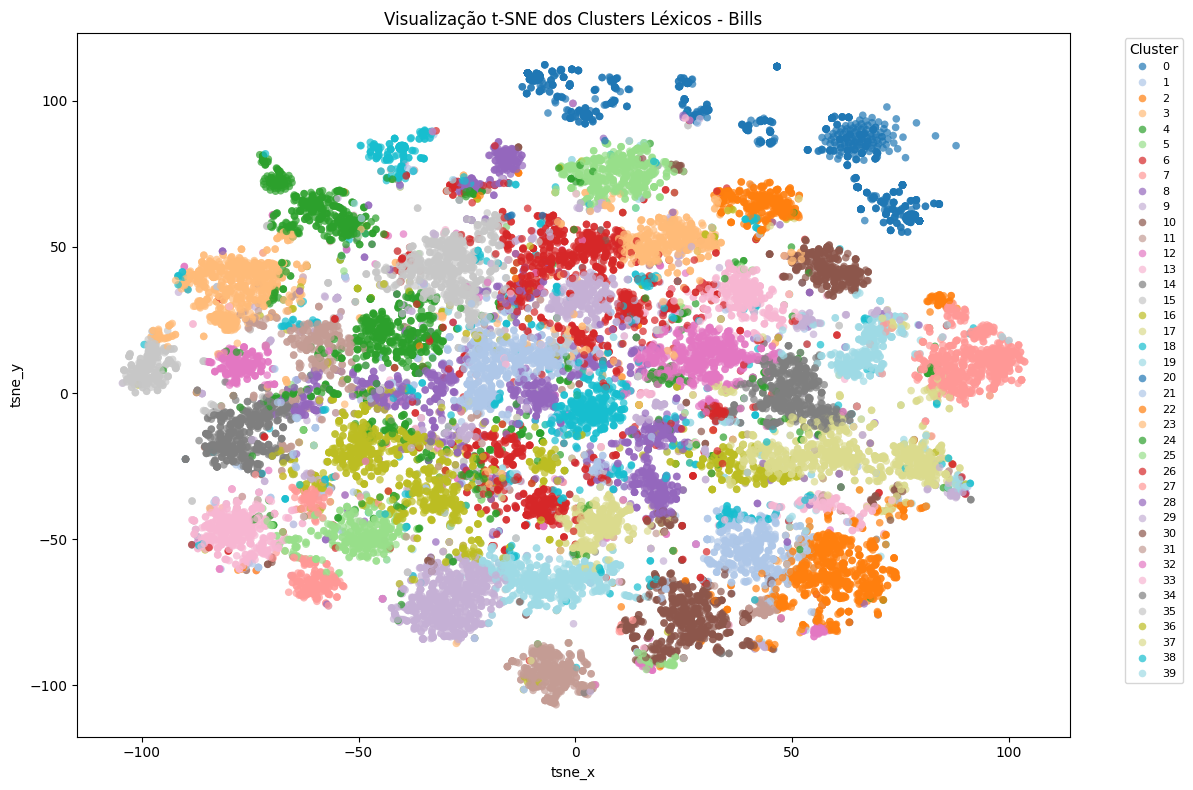

In [ ]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_analise_final_bills,
    x="tsne_x",
    y="tsne_y",
    hue="cluster_principal",
    palette="tab20",
    s=30,
    alpha=0.7,
    linewidth=0
)

plt.title("Visualização t-SNE dos Clusters Léxicos - Bills")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
def selecionar_e_separar_documentos_bills(df_analise, arquivo_jsonl_original,
                                     linhas_originais, total_selecionar=1000):
    metadados_selecao_local = []
    documentos_selecionados = set()

    tamanhos_clusters = df_analise['cluster_principal'].value_counts()
    proporcoes        = tamanhos_clusters / len(df_analise)
    alocacao          = (proporcoes * total_selecionar).round().astype(int)

    diferenca = total_selecionar - alocacao.sum()
    if diferenca != 0:
        for cluster in tamanhos_clusters.index[:abs(diferenca)]:
            alocacao[cluster] += 1 if diferenca > 0 else -1

    dist_intra_media_global = df_analise.groupby('cluster_principal')['dist_intra_media'].mean().mean()

    for cluster_id, cota in alocacao.items():
        df_cluster = df_analise[
            df_analise['cluster_principal'] == cluster_id
        ].sort_values('score_separacao')

        dist_intra_cluster = df_cluster['dist_intra_media'].mean()
        is_cluster_ambiguo = dist_intra_cluster > dist_intra_media_global
        n_ambiguos = int(cota * 0.70) if is_cluster_ambiguo else cota // 2
        n_coesos   = cota - n_ambiguos

        for _, row in df_cluster.head(n_ambiguos).iterrows():
            documentos_selecionados.add(row['arquivo'])
            metadados_selecao_local.append({
                'arquivo': row['arquivo'],
                'cluster': int(cluster_id),
                'tipo'   : 'Ambíguo',
                'score'  : row['score_separacao'],
                'x'      : row['tsne_x'],
                'y'      : row['tsne_y']
            })

        for _, row in df_cluster.tail(n_coesos).iterrows():
            documentos_selecionados.add(row['arquivo'])
            metadados_selecao_local.append({
                'arquivo': row['arquivo'],
                'cluster': int(cluster_id),
                'tipo'   : 'Coeso',
                'score'  : row['score_separacao'],
                'x'      : row['tsne_x'],
                'y'      : row['tsne_y']
            })

    nome_base  = os.path.basename(arquivo_jsonl_original).replace('.jsonl', '')
    caminho_dir = os.path.dirname(os.path.abspath(arquivo_jsonl_original))
    generation_file = os.path.join(caminho_dir, f"generation_{nome_base}_CPS.jsonl")
    assignment_file = os.path.join(caminho_dir, f"assignment_{nome_base}_CPS.jsonl")

    with open(generation_file, 'w', encoding='utf-8') as f_gen, \
         open(assignment_file, 'w', encoding='utf-8') as f_ass:

        for doc_id, linha_bruta in linhas_originais.items():
            if doc_id in documentos_selecionados:
                f_gen.write(linha_bruta)
            else:
                f_ass.write(linha_bruta)

    print(f"generation -> {generation_file}")
    print(f"assignment -> {assignment_file}")
    print("Separação concluída!")

    df_plot = pd.DataFrame(metadados_selecao_local)
    fig = px.histogram(
        df_plot,
        x='cluster',
        color='tipo',
        barmode='group',
        title='Distribuição de Documentos Selecionados (Geração) por Cluster - Bills',
        labels={'cluster': 'ID do Cluster', 'count': 'Qtd. de Documentos Selecionados'},
        color_discrete_map={'Ambíguo': '#EF553B', 'Coeso': '#00CC96'}
    )
    fig.update_layout(xaxis_type='category')
    fig.show()
    return metadados_selecao_local

In [ ]:
import json
import os

total_selecionar_bills = calcular_total_selecionar(len(df_analise_final_bills))
metadados_selecao_bills = selecionar_e_separar_documentos_bills(df_analise_final_bills, target_file_bills, linhas_originais_bills, total_selecionar=total_selecionar_bills)

generation_file_bills = 'generation_bills_CPS.jsonl'

print(f"Verificando arquivo: {generation_file_bills}")

docs_no_jsonl_bills = {}
with open(generation_file_bills, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line.strip())
        h = hash_texto_bills(data['text'])
        docs_no_jsonl_bills[h] = data['text'].strip()

print(f"Documentos encontrados no JSONL: {len(docs_no_jsonl_bills)}")

total_sel_bills = calcular_total_selecionar(len(df_analise_final_bills))

tamanhos_clusters_bills = df_analise_final_bills['cluster_principal'].value_counts()
proporcoes_bills = tamanhos_clusters_bills / len(df_analise_final_bills)
alocacao_bills = (proporcoes_bills * total_sel_bills).round().astype(int)

diferenca = total_sel_bills - alocacao_bills.sum()
if diferenca != 0:
    for cluster in tamanhos_clusters_bills.index[:abs(diferenca)]:
        alocacao_bills[cluster] += 1 if diferenca > 0 else -1

dist_intra_media_global_bills = df_analise_final_bills.groupby('cluster_principal')['dist_intra_media'].mean().mean()

erros_bills = []
sucessos_bills = 0

for cluster_id, cota in alocacao_bills.items():
    df_cluster = df_analise_final_bills[df_analise_final_bills['cluster_principal'] == cluster_id].sort_values('score_separacao')

    dist_intra_cluster = df_cluster['dist_intra_media'].mean()
    is_cluster_ambiguo = dist_intra_cluster > dist_intra_media_global_bills
    n_ambiguos = int(cota * 0.70) if is_cluster_ambiguo else cota // 2
    n_coesos   = cota - n_ambiguos

    esperados = pd.concat([df_cluster.head(n_ambiguos), df_cluster.tail(n_coesos)])

    for _, row in esperados.iterrows():
        doc_id = row['arquivo']
        texto_df = row['texto'].strip()

        if doc_id not in docs_no_jsonl_bills:
            erros_bills.append(f"Erro: Documento {doc_id} do cluster {cluster_id} não encontrado no JSONL.")
        else:
            if docs_no_jsonl_bills[doc_id] != texto_df:
                erros_bills.append(f"Erro: Conteúdo divergente para o documento {doc_id}.")
            else:
                sucessos_bills += 1

if not erros_bills:
    print(f"\nSucesso! Todos os {sucessos_bills} documentos esperados (ambíguos/coesos) estão presentes e corretos no arquivo JSONL.")
else:
    print(f"\nForam encontrados {len(erros_bills)} erros na verificação.")

Seleção probabilística  →  N=26,028 | n_d=260 | K_u=100 | n_s=1,020 | p*≈0.0003
generation -> /content/generation_bills_CPS.jsonl
assignment -> /content/assignment_bills_CPS.jsonl
Separação concluída!


Verificando arquivo: generation_bills_CPS.jsonl
Documentos encontrados no JSONL: 1020
Seleção probabilística  →  N=26,028 | n_d=260 | K_u=100 | n_s=1,020 | p*≈0.0003

Sucesso! Todos os 1020 documentos esperados (ambíguos/coesos) estão presentes e corretos no arquivo JSONL.


In [ ]:
def executar_selecao_e_plot_bills(df_analise, total_selecionar, cluster_id):
    tamanhos_clusters = df_analise['cluster_principal'].value_counts()
    alocacao = (tamanhos_clusters / len(df_analise) * total_selecionar).round().astype(int)

    dif = total_selecionar - alocacao.sum()
    if dif != 0:
        for cl in tamanhos_clusters.index[:abs(dif)]:
            alocacao[cl] += 1 if dif > 0 else -1

    dist_intra_media_global = df_analise.groupby('cluster_principal')['dist_intra_media'].mean().mean()

    metadados_selecao = []

    for cid, cota in alocacao.items():
        df_c = df_analise[df_analise['cluster_principal'] == cid].sort_values('score_separacao')

        dist_intra_cluster = df_c['dist_intra_media'].mean()
        is_cluster_ambiguo = dist_intra_cluster > dist_intra_media_global
        n_amb = int(cota * 0.7) if is_cluster_ambiguo else cota // 2
        n_coe = cota - n_amb

        n_amb = min(n_amb, len(df_c))
        n_coe = min(n_coe, len(df_c) - n_amb)

        for tipo, subset in [('Ambíguo', df_c.head(n_amb)), ('Coeso', df_c.tail(n_coe))]:
            for _, row in subset.iterrows():
                metadados_selecao.append({
                    'arquivo': row['arquivo'],
                    'cluster': int(cid),
                    'tipo': tipo,
                    'x': row['tsne_x'],
                    'y': row['tsne_y'],
                    'score': row['score_separacao']
                })

    selecionados_cluster = [m for m in metadados_selecao if m['cluster'] == cluster_id]
    amb_pts = [m for m in selecionados_cluster if m['tipo'] == 'Ambíguo']
    coe_pts = [m for m in selecionados_cluster if m['tipo'] == 'Coeso']

    print(f"Cluster {cluster_id}  |  Ambíguos: {len(amb_pts)}  |  Coesos: {len(coe_pts)}")
    if not selecionados_cluster:
        print("Nenhum documento selecionado para este cluster.")
        return

    ids_selecionados = {m['arquivo'] for m in selecionados_cluster}
    membros = df_analise[df_analise['cluster_principal'] == cluster_id]
    nao_sel = membros[~membros['arquivo'].isin(ids_selecionados)]

    pad_x = (membros['tsne_x'].max() - membros['tsne_x'].min()) * 0.08 or 1
    pad_y = (membros['tsne_y'].max() - membros['tsne_y'].min()) * 0.08 or 1
    x_range = [membros['tsne_x'].min() - pad_x, membros['tsne_x'].max() + pad_x]
    y_range = [membros['tsne_y'].min() - pad_y, membros['tsne_y'].max() + pad_y]

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=nao_sel['tsne_x'], y=nao_sel['tsne_y'],
        mode='markers',
        marker=dict(symbol='circle', size=8, color='orange', opacity=0.5,
                    line=dict(width=0.5, color='darkorange')),
        name=f'Membros não selecionados (n={len(nao_sel)})',
        text=nao_sel['arquivo'],
        hovertemplate='<b>%{text}</b><extra>Membro</extra>'
    ))

    if coe_pts:
        fig.add_trace(go.Scatter(
            x=[p['x'] for p in coe_pts],
            y=[p['y'] for p in coe_pts],
            mode='markers',
            marker=dict(symbol='triangle-up', size=16, color='royalblue',
                        line=dict(width=1.5, color='white')),
            name=f'Coeso (n={len(coe_pts)})',
            text=[p['arquivo'] for p in coe_pts],
            customdata=[round(p['score'], 4) for p in coe_pts],
            hovertemplate='<b>%{text}</b><br>score: %{customdata}<extra>Coeso</extra>'
        ))

    if amb_pts:
        fig.add_trace(go.Scatter(
            x=[p['x'] for p in amb_pts],
            y=[p['y'] for p in amb_pts],
            mode='markers',
            marker=dict(symbol='triangle-down', size=16, color='crimson',
                        line=dict(width=1.5, color='white')),
            name=f'Ambíguo (n={len(amb_pts)})',
            text=[p['arquivo'] for p in amb_pts],
            customdata=[round(p['score'], 4) for p in amb_pts],
            hovertemplate='<b>%{text}</b><br>score: %{customdata}<extra>Ambíguo</extra>'
        ))

    fig.update_layout(
        title=dict(
            text=f'Cluster {cluster_id} (Bills) — {len(selecionados_cluster)} selecionados '
                 f'(Coesos: {len(coe_pts)} | Ambíguos: {len(amb_pts)})',
            font=dict(size=15)
        ),
        xaxis=dict(range=x_range, title='t-SNE x', showgrid=True, gridcolor='#eee'),
        yaxis=dict(range=y_range, title='t-SNE y', showgrid=True, gridcolor='#eee'),
        template='plotly_white',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
        height=700,
        margin=dict(l=40, r=40, t=80, b=40)
    )
    fig.show()

In [ ]:
total_selecionar_bills = calcular_total_selecionar(len(df_analise_final_bills))

Seleção probabilística  →  N=26,028 | n_d=260 | K_u=100 | n_s=1,020 | p*≈0.0003


In [ ]:
executar_selecao_e_plot_bills(df_analise_final_bills, total_selecionar_bills, cluster_id=5)

Cluster 5  |  Ambíguos: 10  |  Coesos: 10


In [ ]:
generation_file_bills_cps = 'generation_bills_CPS.jsonl'

hashes_generation_bills = {}
with open(generation_file_bills_cps, 'r', encoding='utf-8') as f:
    for line in f:
        d = json.loads(line.strip())
        texto = d.get('text', '')
        if texto.strip():
            h = hash_texto_bills(texto)
            hashes_generation_bills[h] = texto

print(f"Documentos em generation (Bills): {len(hashes_generation_bills)}\n")

dist_intra_media_global_bills = df_analise_final_bills.groupby('cluster_principal')['dist_intra_media'].mean().mean()
tamanhos_clusters_bills = df_analise_final_bills['cluster_principal'].value_counts()
total_sel_bills = calcular_total_selecionar(len(df_analise_final_bills))

alocacao_bills = (tamanhos_clusters_bills / len(df_analise_final_bills) * total_sel_bills).round().astype(int)
dif = total_sel_bills - alocacao_bills.sum()
if dif != 0:
    alocacao_bills[alocacao_bills.index[0]] += dif

print(f"{'Cluster':>8} | {'Tam':>5} | {'Amb':>4} | {'Coe':>4} | {'Amb OK':>8} | {'Coe OK':>8} | {'Ausentes'}")
print("=" * 80)

erros_totais_bills = []

for cluster_id in sorted(df_analise_final_bills['cluster_principal'].unique()):
    df_c = df_analise_final_bills[
        df_analise_final_bills['cluster_principal'] == cluster_id
    ].sort_values('score_separacao')

    cota = alocacao_bills.get(cluster_id, 0)
    dist_intra_cluster = df_c['dist_intra_media'].mean()
    is_ambiguo = dist_intra_cluster > dist_intra_media_global_bills
    n_amb = int(cota * 0.70) if is_ambiguo else cota // 2
    n_coe = cota - n_amb

    esperados_amb = set(df_c.head(n_amb)['arquivo'])
    esperados_coe = set(df_c.tail(n_coe)['arquivo'])
    presentes     = set(hashes_generation_bills.keys())

    ausentes_amb = esperados_amb - presentes
    ausentes_coe = esperados_coe - presentes

    amb_ok = len(ausentes_amb) == 0
    coe_ok = len(ausentes_coe) == 0

    ausentes = list(ausentes_amb | ausentes_coe)
    ausentes_str = str(ausentes[:2])[1:-1] + ("..." if len(ausentes) > 2 else "") if ausentes else "—"

    status_amb = "OK" if amb_ok else f"ERRO({len(ausentes_amb)})"
    status_coe = "OK" if coe_ok else f"ERRO({len(ausentes_coe)})"

    print(f"{cluster_id:>8} | {len(df_c):>5} | {n_amb:>4} | {n_coe:>4} | {status_amb:>8} | {status_coe:>8} | {ausentes_str}")

    if not amb_ok or not coe_ok:
        erros_totais_bills.append(cluster_id)

print("=" * 80)
if not erros_totais_bills:
    print(f"\nVerificação completa: todos os {total_sel_bills} documentos selecionados estão corretamente presentes em {generation_file_bills_cps}")
else:
    print(f"\nClusters com documentos ausentes: {erros_totais_bills}")

In [ ]:
import random
import json
import os
import pandas as pd

def load_jsonl_bills(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]

gen_bills_orig = load_jsonl_bills('generation_bills_CPS.jsonl')
asgn_bills_orig = load_jsonl_bills('assignment_bills_CPS.jsonl')
all_bills_data = gen_bills_orig + asgn_bills_orig

print(f"Total de instâncias Bills: {len(all_bills_data)}")

N_GENERATION_BILLS = len(gen_bills_orig)
SEEDS = [42, 123, 7]

set_gen_original_bills = {hash_texto_bills(d['text']) for d in gen_bills_orig}

results_comparison_bills = []

for i, seed in enumerate(SEEDS, start=1):
    random.seed(seed)
    shuffled = all_bills_data.copy()
    random.shuffle(shuffled)

    gen_split = shuffled[:N_GENERATION_BILLS]
    asgn_split = shuffled[N_GENERATION_BILLS:]

    gen_path = f'generation_bills_random{i}.jsonl'
    asgn_path = f'assignment_bills_random{i}.jsonl'

    with open(gen_path, 'w', encoding='utf-8') as f:
        for obj in gen_split:
            f.write(json.dumps(obj, ensure_ascii=False) + '\n')

    with open(asgn_path, 'w', encoding='utf-8') as f:
        for obj in asgn_split:
            f.write(json.dumps(obj, ensure_ascii=False) + '\n')

    set_gen_random = {hash_texto_bills(d['text']) for d in gen_split}
    overlap = len(set_gen_random.intersection(set_gen_original_bills))

    results_comparison_bills.append({
        'Split': f'Random {i}',
        'Seed': seed,
        'Overlap com Original (CPS) (Docs)': overlap,
        '% de Similaridade': (overlap / N_GENERATION_BILLS) * 100
    })

print("\n--- Comparação de Splits Aleatórios vs Original (CPS) ---")
df_comp_bills = pd.DataFrame(results_comparison_bills)
display(df_comp_bills)

print("\nArquivos gerados com sucesso.")

Total de instâncias Bills: 26028

--- Comparação de Splits Aleatórios vs Original (CPS) ---


,Split,Seed,Overlap com Original (CPS) (Docs),% de Similaridade
0,Random 1,42,44,4.313725
1,Random 2,123,34,3.333333
2,Random 3,7,34,3.333333



Arquivos gerados com sucesso.
